In [2]:
import cv2
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

# Generating A Feature Heatmap

In [8]:
# Note: GaitRecognitionSystem likes to cache inferences to the underlying model.
# Make sure to delete these caches in `GaitRecognitionSystem/data/upload/probe`.
# This with force the program to run model inference again.

path = "external/GaitRecognitionSystem/data/upload/probe"

if os.path.exists(path):
    shutil.rmtree(path)

# Also make sure to clear out any existing gradcam outputs
path = "external/GaitRecognitionSystem/gradcam_frames"

if os.path.exists(path):
    shutil.rmtree(path)

## Gradient Weighted Class Activation Mapping (GradCAM)

Will be using pytorch-grad-cam for model hooking:

`pip install grad-cam`

## Modifying the Inference Code
We need to inject our GradCAM calculations into the model's inference cycle and save the outputs.
Here is the code that will be inserted into `external/GaitRecognitionSystem/model/person_cls/classification.py`

### Imports
Above the current imports insert packages for GradCAM.

```py
#! /usr/bin/python3
# coding=utf-8

# Imports for feature heatmap generation
import cv2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import os
...
```

### Classification.generate()
This method creates the model object, here we do our GradCAM initialization.

```py
def generate(self):
    
    ...

    if self.cuda:
        self.model = nn.DataParallel(self.model)
        self.model = self.model.cuda()

    # ---- GradCAM setup ----
    self.cam_model = self.model.module if isinstance(self.model, torch.nn.DataParallel) else self.model
    self.target_layers = [self.cam_model.features[-1][0]]
    self.cam = GradCAM(model=self.cam_model, target_layers=self.target_layers)

    self.gradcam_dir = os.path.join(os.getcwd(), "gradcam_frames")
    os.makedirs(self.gradcam_dir, exist_ok=True)
    self.frame_counter = 0
    # ------------------------
    # End of self.generate()
```


### Classification.detect_image()
This method runs inference on a single frame of the input video. We will be modifying the method stub to add the optional `frame_id` parameter, seperating out some of the inference logic into multiple steps, running GradCAM, and saving the results. (Comments also translated to english)

```py
def detect_image(self, image, frame_id=None):
    # The code only supports prediction on RGB images; all other image types will be converted to RGB
    image = cvtColor(image)
    # Resize the image without distortion
    image_data = letterbox_image(image, [self.input_shape[1], self.input_shape[0]])
    # Normalize + add batch_size dimension + transpose
    image_data = np.transpose(np.expand_dims(preprocess_input(np.array(image_data, np.float32)), 0), (0, 3, 1, 2))

    with torch.no_grad():
        photo = torch.from_numpy(image_data)
        if self.cuda:
            photo = photo.cuda()

        # Run model normally
        logits = self.model(photo)[0]
        preds = torch.softmax(logits, dim=-1).cpu().numpy()

    class_idx = int(np.argmax(preds))
    class_name = self.class_names[class_idx]
    probability = float(np.max(preds))

    # ---- Generate Grad-CAM heatmap ----
    targets = [ClassifierOutputTarget(class_idx)]
    grayscale_cam = self.cam(input_tensor=photo, targets=targets)
    heatmap = grayscale_cam[0]

    original = np.array(image)

    # Resize CAM to image size
    heatmap = cv2.resize(heatmap, (original.shape[1], original.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    colored_heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(original, 0.6, colored_heatmap, 0.4, 0)

    # Determine frame number
    if frame_id is None:
        frame_id = self.frame_counter
        self.frame_counter += 1

    filename = f"frame_{frame_id:05d}.png"
    save_path = os.path.join(self.gradcam_dir, filename)

    cv2.imwrite(save_path, overlay)
    # ------------------------------------

    return class_name, probability

```


In [9]:
# The output will be put into external/GaitRecognition/gradcam_frames and .png frames
# Use this code to reconstruct the video
# Simple video reconstruction code written by AI

frame_folder = "external/GaitRecognitionSystem/gradcam_frames"

# Output video
output_video = "gradcam_video.mp4"
fps = 15

# Get sorted frame list
frames = sorted([
    f for f in os.listdir(frame_folder)
    if f.endswith(".png")
])
if len(frames) == 0:
    raise RuntimeError("No frames found in folder.")

# Read first frame to get size
first_frame_path = os.path.join(frame_folder, frames[0])
frame = cv2.imread(first_frame_path)

height, width, _ = frame.shape

# Initialize video writer
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
video = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

# Write frames
for f in frames:
    frame_path = os.path.join(frame_folder, f)
    img = cv2.imread(frame_path)
    video.write(img)

video.release()

print("Video saved to:", output_video)

Video saved to: gradcam_video.mp4


## Outputs
View output videos in `demo_videos/feature_heatmap_videos` with the same name as the original data.

# Spatiotemporal CAM

In [14]:
len(frames[25:])

169

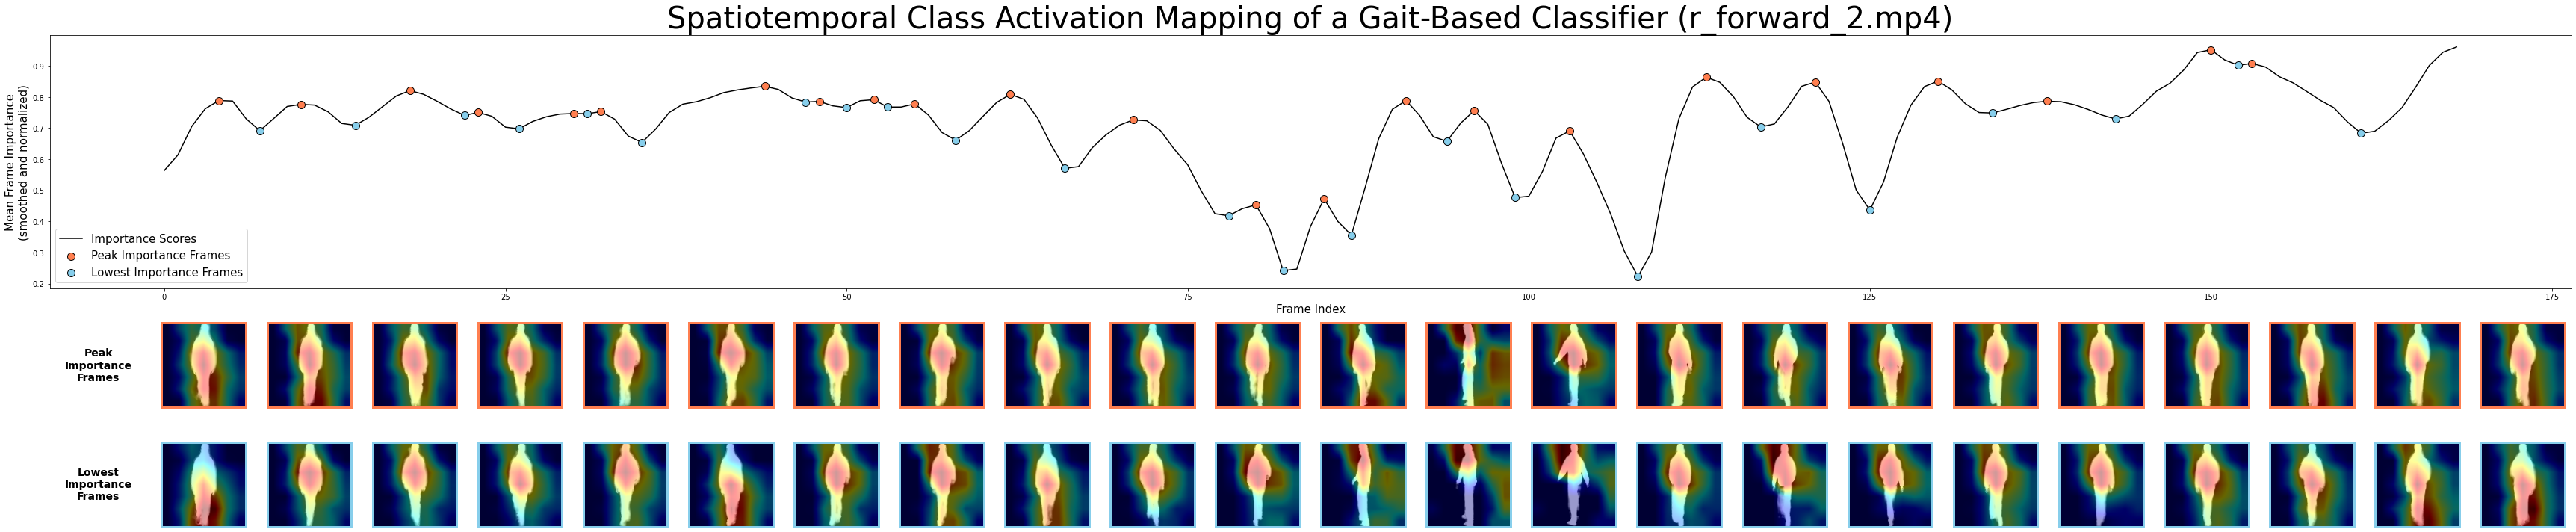

In [17]:
PEAK_COLOR = 'coral'
VALLEY_COLOR = 'skyblue'
TITLE = 'Spatiotemporal Class Activation Mapping of a Gait-Based Classifier (r_forward_2.mp4)'

frame_folder = "external/GaitRecognitionSystem/gradcam_frames"

frames = sorted([
    f for f in os.listdir(frame_folder)
    if f.endswith(".png")
])

frames = frames[25:]
importance_scores = []
for f in frames:
    path = os.path.join(frame_folder, f)
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = gray / 255.0
    importance = np.mean(gray)
    importance_scores.append(importance)

importance_scores = np.array(importance_scores)
# Normalize importance scores
scores = (importance_scores - importance_scores.min()) / (
          importance_scores.max() - importance_scores.min())


scores_smooth = gaussian_filter1d(scores, sigma=1)
peaks, _ = find_peaks(scores_smooth)
valleys, _ = find_peaks(-scores_smooth)

peaks = np.delete(peaks, [])
valleys = np.delete(valleys, [])

peak_frames = [frames[p] for p in peaks]
valley_frames = [frames[v] for v in valleys]

n_peak = len(peak_frames)
n_valley = len(valley_frames)
img_cols_peak = n_peak
img_cols_valley = n_valley

# --- Layout: extra left column for headers ---
total_cols = max(img_cols_peak, img_cols_valley) + 1  # +1 for header

fig = plt.figure(figsize=(2*total_cols, 10), facecolor='white')
gs = GridSpec(3, total_cols, figure=fig, height_ratios=[3, 1, 1])

# ---------------- Signal Plot ----------------
ax_signal = fig.add_subplot(gs[0, :])
ax_signal.plot(scores_smooth, label='Importance Scores', color='black', zorder=1)
ax_signal.scatter(peaks, scores_smooth[peaks],
                  label="Peak Importance Frames", marker='o', color=PEAK_COLOR, s=100, edgecolors='black', zorder=2)
ax_signal.scatter(valleys, scores_smooth[valleys],
                  label="Lowest Importance Frames", marker='o', color=VALLEY_COLOR, s=100, edgecolors='black', zorder=2)
ax_signal.set_title(TITLE, size=40)
ax_signal.set_xlabel("Frame Index", size=15)
ax_signal.set_ylabel("Mean Frame Importance\n(smoothed and normalized)", size=15)
ax_signal.legend(
    loc='lower left', fontsize=15
)

# ---------------- Peak Frames Row ----------------
# Left header
ax_header = fig.add_subplot(gs[1, 0])
ax_header.axis("off")
ax_header.text(0.5, 0.5, "Peak\nImportance\nFrames", verticalalignment='center', horizontalalignment='center', fontsize=14, fontweight='bold')

# Images
for i, frame in enumerate(peak_frames):
    ax = fig.add_subplot(gs[1, i+1])  # shift right by 1 column
    img = plt.imread(os.path.join(frame_folder, frame))
    ax.imshow(img)
    ax.set_xticks([])
    ax.set_yticks([])
    # Blue border
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(PEAK_COLOR)
        spine.set_linewidth(3)

# ---------------- Valley Frames Row ----------------
# Left header
ax_header = fig.add_subplot(gs[2, 0])
ax_header.axis("off")
ax_header.text(0.5, 0.5, "Lowest\nImportance\nFrames", verticalalignment='center', horizontalalignment='center', fontsize=14, fontweight='bold')

# Images
for i, frame in enumerate(valley_frames):
    ax = fig.add_subplot(gs[2, i+1])  # shift right by 1 column
    img = plt.imread(os.path.join(frame_folder, frame))
    ax.imshow(img)
    ax.set_xticks([])
    ax.set_yticks([])
    # Red border
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(VALLEY_COLOR)
        spine.set_linewidth(3)

plt.tight_layout()
plt.show()